# MARL Notebook

### Using Jax for speedy reinforcement learning

Motivation: After developing our environment and training schedule, we ran into time and compute constraints
- Could not run more than ~40 envs on our computer, which for many timesteps took hours

Solution: Use Jax (via MuJoCo Playground environments) to speed things up
- Run in Google collab to get around Jax GPU OS constraints (Jax GPU is meant to run on Linux)

### Background

Jax compiles Python code into optimized machine code (usually via XLA)
- Traces Python functions, builds computation graph, generates machine code for device (GPU in this case)
- Jax can then reuse compiled code, which (combined with GPU speed), makes computations very fast
  - Caveats: Have to make some adjustments (e.g. no inner for loops as they cannot be vectorized by Jax)

Since Jax/JIT traces operations and builds a computation graph, we want to keep things relatively simple to avoid long computations
- Created a new Crazyflie XMl without all the collision geoms to speed things up
  - Previously, the physics integrator had to consider all collisions even if we never actually collided with anything
  - We weren't using these geoms anyway, as we end training episodes if drone(s) get to close to the ground or one another ("crash" but no collision)

### Resources

[MuJoCo Playground](https://github.com/google-deepmind/mujoco_playground) with example [Cartpole Balance RL Notebook](https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/dm_control_suite.ipynb)


In [1]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install playground

# Rendering video
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.5/736.5 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.1/344.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 132.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.8 MB/s eta 0:00:00


In [2]:
# @title Check if MuJoCo installation was successful and ensure correct config

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


In [3]:
# @title Crazyflie Config

from mujoco_playground._src import mjx_env
import mujoco
from mujoco import mjx
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

import mediapy as media
from typing import Any

# Importing Scene from Google Drive (mounted folder)
# Using simplified models without collisions to reduce Jax graph computations
# Don't use collisions anyway, env terminates if drone is near ground
SCENE_PATH_1_DRONE = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene.xml"
SCENE_PATH_2_DRONES = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene_multi.xml"

# Adjust XML scene and number of training steps based on number of drones
NUM_DRONES = 2
SCENE_PATH = SCENE_PATH_2_DRONES if NUM_DRONES > 1 else SCENE_PATH_1_DRONE
PPO_TIMESTEPS = 150_000_000 if NUM_DRONES > 1 else 75_000_000

# Basic info
BASE_HOVER_THRUST = 0.26487
TARGET_POS = jnp.array([0.0, 0.0, 0.5])
QPOS_PER_DRONE = 7  # pos + quat
QVEL_PER_DRONE = 6  # linear vel + angular vel
ACTION_SIZE_PER_DRONE = 4 # Thrust, roll, pitch, yaw

# Random starting state sampled from distribution
TRAINING_POS_RANGE = 2.0
DRONE_SPACING_ALONG_AXIS = 0.4
TRAINING_QUAT_RANGE = np.pi / 8
TRAINING_VEL_RANGE = 0.2
TRAINING_ANG_VEL_RANGE = 0.1

# Out of bounds if N distance further from target compared to starting distance
OUT_OF_BOUNDS_RANGE = 2.0

# Reward and observation constants
TERMINATION_WEIGHT = 1.0
SURVIVAL_WEIGHT = TERMINATION_WEIGHT / 1000
DRONE_PROXIMITY_WEIGHT = 0.01
TARGET_PROXIMITY_WEIGHT = 0.01

DRONE_PROXIMITY_THRESHOLD = 0.25
DRONE_COLLISION_THRESHOLD = 0.1

N_PREV_ACTIONS = 4


# Helper function to convert drone quaternion to rotation matrix
def quat_to_rotation_matrix(q):
    """q is [w, x, y, z]"""
    w, x, y, z = q
    return jnp.array([
        [1 - 2*(y**2 + z**2), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),       1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),       2*(y*z + x*w),     1 - 2*(x**2 + y**2)]
    ])

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
mujoco_menagerie not found. Downloading...


Cloning mujoco_menagerie: ██████████| 100/100 [00:39<00:00]


Checking out commit 14ceccf557cc47240202f2354d684eca58ff8de4
Successfully downloaded mujoco_menagerie


In [12]:
# @title Crazyflie Env

class CrazyflieEnv(mjx_env.MjxEnv):
    """MJX environment using the Crazyflie drone model."""

    def __init__(self):
        # Define environment configuration (control and sim time steps)
        cfg = config_dict.ConfigDict()
        cfg.ctrl_dt = 0.02    # control step (50Hz)
        cfg.sim_dt = 0.002    # simulation step (500Hz)
        super().__init__(cfg)

        # Load MuJoCo model and convert to MJX
        self._mj_model = mujoco.MjModel.from_xml_path(SCENE_PATH)
        self._mjx_model = mjx.put_model(self._mj_model)

        # Define control/action size as number of actuators (e.g. 8 for 2 drones)
        self._action_size = self._mj_model.nu

        # If using multiple drones, arrange them in a line (along X axis for now)
        self.dir_x, self.dir_y = 1.0, 0.0
        self.drone_offsets = jnp.linspace(-(NUM_DRONES - 1) / 2, (NUM_DRONES - 1) / 2, NUM_DRONES) * DRONE_SPACING_ALONG_AXIS


    # Expected env properties for Brax PPO training
    @property
    def xml_path(self) -> str:
        return SCENE_PATH

    @property
    def action_size(self) -> int:
        return self.mjx_model.nu

    @property
    def mj_model(self) -> mujoco.MjModel:
        return self._mj_model

    @property
    def mjx_model(self) -> mjx.Model:
        return self._mjx_model


    def reset(self, rng: jax.Array) -> mjx_env.State:
        """Vectorized reset for Crazyflie drones."""

        # Random keys
        rng, rng_pos, rng_quat, rng_vel, rng_ang = jax.random.split(rng, 5)

        # Random starting positions for drone(s) based on the target pos
        std_pos = TRAINING_POS_RANGE / 2.0
        pos_noise = jax.random.normal(rng_pos, (NUM_DRONES, 3)) * std_pos
        start_pos = TARGET_POS + pos_noise
        start_pos = start_pos.at[:, 2].set(jnp.clip(start_pos[:, 2], 0.1, jnp.inf))

        # Drone offset along drones starting axis
        offset_xy = jnp.stack([
            self.drone_offsets * self.dir_x,
            self.drone_offsets * self.dir_y,
            jnp.zeros_like(self.drone_offsets)
        ], axis=1)
        start_pos += offset_xy

        # Random quaternions
        std_angle = TRAINING_QUAT_RANGE / 2.0
        axes = jax.random.normal(rng_quat, (NUM_DRONES, 3))
        axes = axes / jnp.linalg.norm(axes, axis=1, keepdims=True)
        angles = jax.random.normal(rng_quat, (NUM_DRONES,)) * std_angle
        w = jnp.cos(angles)
        quats = jnp.concatenate([w[:, None], axes * jnp.sin(angles)[:, None]], axis=1)

        # Linear and angular velocities
        lin_vel = (TRAINING_VEL_RANGE / 2.0) * jax.random.normal(rng_vel, (NUM_DRONES, 3))
        ang_vel = (TRAINING_ANG_VEL_RANGE / 2.0) * jax.random.normal(rng_ang, (NUM_DRONES, 3))

        # Assemble qpos/qvel in batch
        qpos = jnp.zeros((NUM_DRONES, QPOS_PER_DRONE), dtype=jnp.float32)
        qpos = qpos.at[:, 0:3].set(start_pos)
        qpos = qpos.at[:, 3:7].set(quats)
        qpos = qpos.reshape(-1)  # flatten for mjx_env

        qvel = jnp.zeros((NUM_DRONES, QVEL_PER_DRONE), dtype=jnp.float32)
        qvel = qvel.at[:, 0:3].set(lin_vel)
        qvel = qvel.at[:, 3:6].set(ang_vel)
        qvel = qvel.reshape(-1)  # flatten for mjx_env

        # Initialize state
        action_history = jnp.zeros((N_PREV_ACTIONS, NUM_DRONES, ACTION_SIZE_PER_DRONE))
        initial_distance = jnp.linalg.norm(start_pos - TARGET_POS, axis=1)

        data = mjx_env.init(self._mjx_model, qpos=qpos, qvel=qvel)

        # Metrics
        metrics = {
            "reward/distance_improvement": jnp.zeros(()),
            "reward/proximity_bonus": jnp.zeros(()),
            "reward/survival_bonus": jnp.zeros(()),
            "reward/termination": jnp.zeros(()),
            "reward/drone_proximity_penalty": jnp.zeros(()),
            "reward": jnp.zeros(())
        }

        # State info
        info = {
            "rng": rng,
            "initial_distance": initial_distance,
            "prev_pos": start_pos,
            "action_history": action_history, # (N_prev_actions, N_drones, Action)
        }

        reward = jnp.zeros(())
        done = jnp.zeros(())

        obs = self._get_obs(data, info)

        return mjx_env.State(data=data, obs=obs, reward=reward, done=done, metrics=metrics, info=info)


    def step(self, state: mjx_env.State, action: jax.Array) -> mjx_env.State:
        """Vectorized Crazyflie step for multiple drones with MARL rewards."""

        # Clip flat action (by default done via XML actuators but we are also recording action history)
        action_clipped = action.at[0::4].set(jnp.clip(action[0::4], 0.0, 0.35))   # thrusts
        action_clipped = action_clipped.at[1::4].set(jnp.clip(action[1::4], -1.0, 1.0))  # rolls
        action_clipped = action_clipped.at[2::4].set(jnp.clip(action[2::4], -1.0, 1.0))  # pitches
        action_clipped = action_clipped.at[3::4].set(jnp.clip(action[3::4], -1.0, 1.0))  # yaws

        data = mjx_env.step(self._mjx_model, state.data, action_clipped, n_substeps=self.n_substeps)
        obs = self._get_obs(data, state.info)

        qpos = data.qpos.reshape(NUM_DRONES, QPOS_PER_DRONE)

        # Retrieve stateful info for drone(s)
        prev_pos = state.info["prev_pos"]
        init_dist = state.info["initial_distance"]

        # Dynamic step rewards: Distance to target improvement and target proximity
        pos = qpos[:, :3]
        distance_to_target = jnp.linalg.norm(TARGET_POS - pos, axis=1)
        distance_to_target_old = jnp.linalg.norm(TARGET_POS - prev_pos, axis=1)
        distance_improvement = distance_to_target_old - distance_to_target

        proximity_bonus = TARGET_PROXIMITY_WEIGHT * (1 - jnp.tanh(distance_to_target))

        # Compute pairwise distances between drones
        diffs = pos[:, None, :] - pos[None, :, :]  # (N, N, 3)
        dists = jnp.linalg.norm(diffs + jnp.eye(NUM_DRONES)[..., None] * 1e9, axis=-1)  # (N, N)

        # Proximity penalty for being closer than threshold to another drone
        proximity_penalty_matrix = jnp.where(
            dists < DRONE_PROXIMITY_THRESHOLD,
            DRONE_PROXIMITY_WEIGHT * (1.0 - dists / DRONE_PROXIMITY_THRESHOLD),
            0.0,
        )
        # Zero out self-distances
        proximity_penalty_matrix = proximity_penalty_matrix * (1.0 - jnp.eye(NUM_DRONES))
        drone_proximity_penalty = jnp.sum(proximity_penalty_matrix, axis=1)

        # Collision check
        collision_matrix = (dists < DRONE_COLLISION_THRESHOLD).astype(jnp.float32)
        collision_any = jnp.clip(jnp.sum(collision_matrix * (1 - jnp.eye(NUM_DRONES)), axis=1), 0, 1)

        # Termination conditions: Crash, stray from target, drone collision
        done_per_drone = (
            (pos[:, 2] < 0.05)
            | (distance_to_target > init_dist + OUT_OF_BOUNDS_RANGE)
            | (collision_any > 0)
        )

        # Reward per drone, 1D jax arrays of shape (NUM_DRONES,)
        reward_per_drone = (
            SURVIVAL_WEIGHT
            + proximity_bonus
            + distance_improvement
            - drone_proximity_penalty
            - done_per_drone.astype(jnp.float32) * TERMINATION_WEIGHT
        )

        # Aggregate (mean) reward for the environment
        reward = jnp.mean(reward_per_drone)
        done_all = jnp.any(done_per_drone).astype(jnp.float32)

        # Aggregate per-drone metrics to scalars per environment (match Brax format)
        new_metrics = {
            "reward/distance_improvement": jnp.mean(distance_improvement),
            "reward/proximity_bonus": jnp.mean(proximity_bonus),
            "reward/survival_bonus": SURVIVAL_WEIGHT * NUM_DRONES,
            "reward/termination": - done_all * TERMINATION_WEIGHT,
            "reward/drone_proximity_penalty": - jnp.mean(drone_proximity_penalty),
            "reward": reward,
        }

        # Reshape flat action back to per drone, update action history
        actions_per_drone = action_clipped.reshape(NUM_DRONES, ACTION_SIZE_PER_DRONE)
        new_action_history = jnp.concatenate(
            [state.info["action_history"][1:],
            actions_per_drone[jnp.newaxis, ...]],
            axis=0
        )

        # Update info (prev pos and action history)
        new_info = dict(state.info)
        new_info["prev_pos"] = pos
        new_info["action_history"] = new_action_history

        return mjx_env.State(
            data=data,
            obs=obs,
            reward=reward,
            done=done_all,
            metrics=new_metrics,
            info=new_info,
        )


    # Obs per-drone: pos + vel + angular velocity + Rotation mat + relative pos (body) + vel (body) + Act history
    # Per-drone: 3 + 3 + 3 + 9 + 3 + 3 + history_length * 4
    def _get_obs(self, data, info):
        qpos = data.qpos.reshape(NUM_DRONES, QPOS_PER_DRONE)
        qvel = data.qvel.reshape(NUM_DRONES, QVEL_PER_DRONE)

        # Convert drone(s) quat to rotation matrix
        quat = qpos[:, 3:7]
        rot_mats = jax.vmap(quat_to_rotation_matrix)(quat) # (N, 3, 3)

        # Get relative position to target in drone body coordinates
        pos = qpos[:, :3]
        pos_error = TARGET_POS - pos # (N, 3)
        rel_pos_body = jnp.einsum('nij,nj->ni', rot_mats.transpose((0, 2, 1)), pos_error)

        # Get linear velocity in drone body coordinates
        vel = qvel[:, :3]
        linear_vel_body = jnp.einsum('nij,nj->ni', rot_mats.transpose((0, 2, 1)), vel)

        ang_vel = qvel[:, 3:6]

        # Base state (per drone)
        core = jnp.concatenate(
            [pos, vel, ang_vel, rot_mats.reshape(NUM_DRONES, -1), rel_pos_body, linear_vel_body],
            axis=1,
        )

        # Append action history per drone
        def obs_for_drone(i):
            act_hist_flat = info["action_history"][:, i, :].reshape(-1)
            return jnp.concatenate([core[i], act_hist_flat])

        obs_per_drone = jax.vmap(obs_for_drone)(jnp.arange(NUM_DRONES))

        # Final flattened observation
        return obs_per_drone.reshape(-1)

In [ ]:
# @title Crazyflie Rollout Example

def run_rollout():
    env = CrazyflieEnv()
    jit_env_reset = jax.jit(env.reset)
    jit_env_step = jax.jit(env.step)

    key = jax.random.PRNGKey(42)
    state = jit_env_reset(key)
    rollout = [state]

    episode_length = 1000

    print("Crazyflie Test Rollout")
    print("Starting pos:", np.asarray(state.info["prev_pos"]))
    print(f"Initial obs shape: {state.obs.shape}")
    print("=" * 60)

    for i in range(episode_length):
        # Thrust up action
        action = jnp.tile(jnp.array([BASE_HOVER_THRUST + 0.05, 0.0, 0.0, 0.0]), (NUM_DRONES,))

        # Step the environment
        state = jit_env_step(state, action)
        rollout.append(state)

        # Convert JAX arrays to NumPy for readable printing
        metrics_np = jax.tree_util.tree_map(
            lambda x: np.asarray(x).item() if np.size(x) == 1 else np.asarray(x),
            state.metrics
        )
        ctrl_np = np.asarray(action)
        prev_pos_np = np.asarray(state.info.get("prev_pos", np.zeros(3)))

        # Parse Obs
        obs_np = np.asarray(state.obs)
        pos = obs_np[0:3]
        lin_vel = obs_np[3:6]
        ang_vel = obs_np[6:9]

        # Assuming action history length >= 1
        last_action = obs_np[24:28]

        # Logs
        print(f"\n\nStep {i:04d}, Action {ctrl_np}, Reward {float(state.reward):+.4f}")
        print(f"  \nReward breakdown")
        print(f"    Dist Improvement: {metrics_np.get('reward/distance_improvement', np.nan):+.4f}")
        print(f"    Target Proximity Bonus: {metrics_np.get('reward/proximity_bonus', np.nan):+.4f}")
        print(f"    Survival Bonus: {metrics_np.get('reward/survival_bonus', np.nan):+.4f}")
        print(f"    Drone Proximity Penalty: {metrics_np.get('reward/drone_proximity_penalty', np.nan):+.4f}")
        print(f"    Termination: {metrics_np.get('reward/termination', np.nan):+.4f}")

        print(f"  \nPartial observation breakdown for drone 1")
        print(f"    Pos:          {pos}")
        print(f"    Linear vel:   {lin_vel}")
        print(f"    Angular vel:  {ang_vel}")
        print(f"    Last Action:  {last_action}")

        # Terminate if done
        if bool(state.done):
            print(f"\nEnvironment terminated at step {i} (done=True)")
            break

    # Utility to render target as geom in scene
    print("\nRendering trajectory...")
    target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")

    def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
        scene.geoms[target_geom_id].pos[:] = target_pos

    modify_target_fn = lambda scene: move_target_geom(scene, TARGET_POS)

    # Collect frames, use track camera from xml scene and update geom pos to target pos
    frames = env.render(
        rollout,
        camera="track",
        modify_scene_fns=[modify_target_fn] * len(rollout),
    )
    media.show_video(frames, fps=1.0 / env.dt)

    # Summary
    rewards = [float(s.reward) for s in rollout]
    print(f"\nTotal steps: {len(rewards)}, Final reward: {rewards[-1]:.4f}")

run_rollout()

Crazyflie Test Rollout
Starting pos: [[ 0.40576404  0.7990441   0.1       ]
 [-0.43525755 -1.2226585   0.1       ]]
Initial obs shape: (80,)


Step 0000, Action [0.31487 0.      0.      0.      0.31487 0.      0.      0.     ], Reward +0.0034
  
Reward breakdown
    Dist Improvement: +0.0006
    Target Proximity Bonus: +0.0019
    Survival Bonus: +0.0020
    Drone Proximity Penalty: -0.0000
    Termination: -0.0000
  
Partial observation breakdown for drone 1
    Pos:          [0.40536225 0.796171   0.09709126]
    Linear vel:   [-0.01198793 -0.15057793 -0.12737767]
    Angular vel:  [0.03274024 0.00869081 0.08009031]
    Last Action:  [0. 0. 0. 0.]


Step 0001, Action [0.31487 0.      0.      0.      0.31487 0.      0.      0.     ], Reward +0.0038
  
Reward breakdown
    Dist Improvement: +0.0010
    Target Proximity Bonus: +0.0019
    Survival Bonus: +0.0020
    Drone Proximity Penalty: -0.0000
    Termination: -0.0000
  
Partial observation breakdown for drone 1
    Pos:          [

100%|██████████| 97/97 [00:00<00:00, 269.96it/s]


This browser does not support the video tag.



Total steps: 97, Final reward: -0.5553


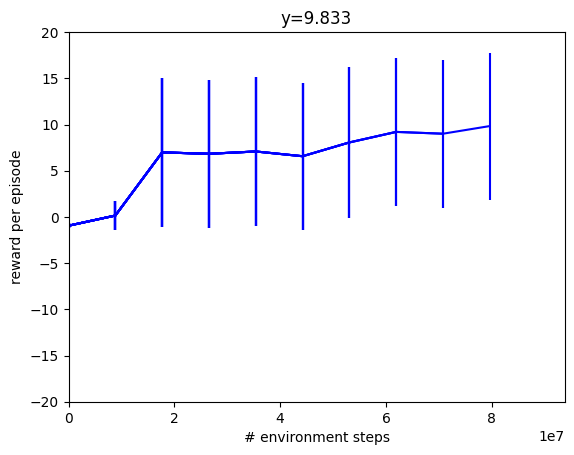

time to jit: 0:01:03.339024
time to train: 0:20:48.004348


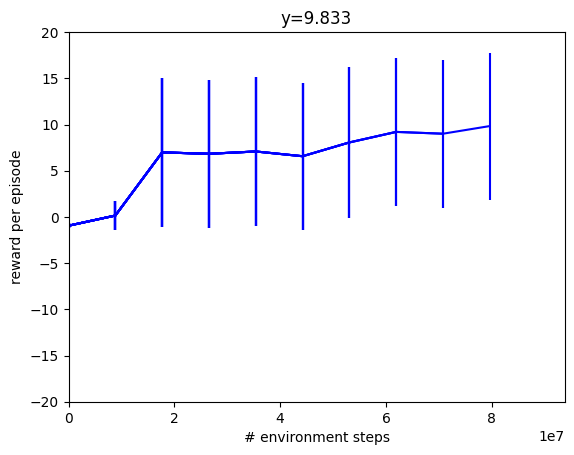

In [ ]:
# @title Crazyflie PPO Training - Single Agent or Centralized Multi-Agent (critic and agents)

from datetime import datetime
import functools
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import mediapy as media
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

from mujoco_playground import wrapper
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from mujoco_playground.config import dm_control_suite_params


# Progress plots
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]
def progress(num_steps, metrics):
    clear_output(wait=True)
    times.append(datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.ylim([-20, 20])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"y={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")
    display(plt.gcf())

# Anneal LR
def linear_annealing_lr(init_lr, final_lr, num_timesteps):
    def schedule(step):
        progress = step / num_timesteps
        return init_lr + progress * (final_lr - init_lr)
    return schedule

# PPO training parameters
ppo_params = config_dict.create(
    num_timesteps=PPO_TIMESTEPS,
    num_evals=10,
    episode_length=1500,
    normalize_observations=True,
    action_repeat=1,
    unroll_length=30,
    num_minibatches=32,
    num_updates_per_batch=16,
    discounting=0.995,
    learning_rate=linear_annealing_lr(3e-3, 3e-5,  PPO_TIMESTEPS),
    entropy_cost=1e-3,
    num_envs=2048,
    batch_size=1024,
)

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params.network_factory
    )

train_fn = functools.partial(
    ppo.train,
    **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

# Create environment
env = CrazyflieEnv()

# Train PPO agent - make_inference_fn is our policy function, params are network parameters, metrics are training stats
# Wrap env for training to match Brax format (e.g. add device and env dimensions to obs)
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [ ]:
#@title Crazyflie PPO Evaluation
env = CrazyflieEnv()

jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(ppo_params["episode_length"]):
    if bool(state.done):
        break
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

    # Logs
    metrics_np = jax.tree_util.tree_map(lambda x: np.asarray(x).item() if np.size(x) == 1 else np.asarray(x), state.metrics)
    ctrl_np = np.asarray(ctrl)
    prev_pos_np = np.asarray(state.info.get("prev_pos", np.zeros(3)))

    # Print progress
    print(f"\nStep {i:04d}: Action {[f'{x:.4f}' for x in ctrl_np]}")
    print(
        f"Rewards: | "
        f"Dist Impr: {metrics_np.get('reward/distance_improvement', np.nan):.4f} | "
        f"Target Prox: {metrics_np.get('reward/proximity_bonus', np.nan):.4f} | "
        f"Survival: {metrics_np.get('reward/survival_bonus', np.nan):.4f} | "
        f"Drone Prox: {metrics_np.get('reward/drone_proximity_penalty', np.nan):+.4f} | "
        f"Termination: {metrics_np.get('reward/termination', np.nan):+.4f}"
    )
    print(f"Prev Pos: {prev_pos_np}")


# Utility to render target as geom in scene based on env target pos
target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")
def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
    scene.geoms[target_geom_id].pos[:] = target_pos

frames = env.render(rollout, camera="track", modify_scene_fns=[lambda scene: move_target_geom(scene, TARGET_POS)]*len(rollout))

rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt)


Step 0000: Action ['0.7923', '-0.6968', '0.1258', '0.2599', '0.7816', '-0.4247', '-0.6656', '0.4132']
Rewards: | Dist +/-: 0.0007 | Target Prox: 0.0019 | Survival: 0.0020 | Drone Prox: -0.0000 | Termination: -0.0000
Prev Pos: [[ 0.40538028  0.7961555   0.09735033]
 [-0.4346894  -1.2232963   0.10103275]]

Step 0001: Action ['0.7915', '-0.6933', '0.1162', '0.2543', '0.7811', '-0.4259', '-0.6620', '0.4088']
Rewards: | Dist +/-: 0.0013 | Target Prox: 0.0019 | Survival: 0.0020 | Drone Prox: -0.0000 | Termination: -0.0000
Prev Pos: [[ 0.40535673  0.7929574   0.09594067]
 [-0.4342228  -1.223675    0.10331872]]

Step 0002: Action ['0.7933', '-0.4324', '0.5139', '0.2182', '0.7868', '-0.1686', '-0.5691', '0.2510']
Rewards: | Dist +/-: 0.0018 | Target Prox: 0.0019 | Survival: 0.0020 | Drone Prox: -0.0000 | Termination: -0.0000
Prev Pos: [[ 0.40569344  0.7894457   0.09577023]
 [-0.433854   -1.2238002   0.10685733]]

Step 0003: Action ['0.7917', '-0.5114', '0.5643', '0.2095', '0.7628', '-0.1848', 

100%|██████████| 92/92 [00:00<00:00, 185.79it/s]


This browser does not support the video tag.


In [29]:
# @title Crazyflie MAPPO Training (Centralized Critic, Decentralized Agents)

import functools
from typing import Any, Callable, Tuple

import jax
import jax.numpy as jnp
import numpy as np
import optax
import flax.linen as nn
from flax.training.train_state import TrainState
from dataclasses import dataclass

# ---------------------------
# Hyperparameters / settings
# ---------------------------
NUM_ENVS = 64
ROLLOUT_STEPS = 128
NUM_EPOCHS = 4
MINI_BATCH_SIZE = 256
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS = 0.2
ENT_COEF = 1e-3
VF_COEF = 1.0
MAX_GRAD_NORM = 0.5
LR = 3e-4
SEED = 42
POLICY_HIDDEN = [128, 128]
VF_HIDDEN = [128, 128]


# ---------------------------
# Utilities
# ---------------------------

def flatten(x):
    return jnp.reshape(x, (x.shape[0], -1)) if x.ndim > 1 else x

# Safe scalar clipping (for jax.grad stability)
def clip_by_global_norm(updates, max_norm):
    g_norm = jnp.sqrt(sum([jnp.sum(jnp.square(p)) for p in jax.tree_util.tree_leaves(updates)]))
    trigger = g_norm < max_norm
    coef = jnp.where(trigger, 1.0, max_norm / (g_norm + 1e-6))
    return jax.tree_util.tree_map(lambda p: p * coef, updates)

# ---------------------------
# Models (Flax)
# ---------------------------

class MLP(nn.Module):
    hidden_sizes: Tuple[int, ...]
    activate_final: bool = False

    @nn.compact
    def __call__(self, x):
        for i, h in enumerate(self.hidden_sizes):
            x = nn.relu(nn.Dense(h)(x))
        if self.activate_final:
            x = nn.relu(x)
        return x

class Actor(nn.Module):
    """Per-agent Gaussian policy (diagonal Gaussian)."""
    hidden_sizes: Tuple[int, ...]
    action_dim: int

    @nn.compact
    def __call__(self, x):
        # x: (..., obs_dim_per_agent)
        h = MLP(self.hidden_sizes)(x)
        mean = nn.Dense(self.action_dim)(h)
        # parameterize log_std as a trainable independent parameter (per-action)
        log_std = self.param("log_std", nn.initializers.zeros, (self.action_dim,))
        # broadcast log_std to x.shape[:-1] + (action_dim,)
        log_std_b = jnp.broadcast_to(log_std, mean.shape)
        return mean, log_std_b

class CentralizedCritic(nn.Module):
    """Takes global joint observation (all agents concatenated) -> scalar value."""
    hidden_sizes: Tuple[int, ...]
    @nn.compact
    def __call__(self, x):
        h = MLP(self.hidden_sizes)(x)
        v = nn.Dense(1)(h)
        return jnp.squeeze(v, -1)  # (batch,)

# ---------------------------
# TrainState wrappers
# ---------------------------

@dataclass
class PPOTrainState:
    policy_state: TrainState
    value_state: TrainState

# ---------------------------
# Helpers: action sampling, log probs
# ---------------------------

def gaussian_log_prob(mean, log_std, action):
    # mean, log_std, action shapes: (..., action_dim)
    var = jnp.exp(2.0 * log_std)
    logp = -0.5 * (((action - mean) ** 2) / (var + 1e-8) + 2 * log_std + jnp.log(2 * jnp.pi))
    return jnp.sum(logp, axis=-1)  # sum over action dim

def sample_action(rng, mean, log_std):
    eps = jax.random.normal(rng, mean.shape)
    action = mean + jnp.exp(log_std) * eps
    logp = gaussian_log_prob(mean, log_std, action)
    return action, logp

# ---------------------------
# Build vectorized environment fns
# ---------------------------

# Create env and infer shapes
def make_env_and_infer():
    env = CrazyflieEnv()
    key = jax.random.PRNGKey(0)
    st = env.reset(key)
    obs = st.obs

    # obs is flattened across drones: shape (per_env_obs_dim,)
    per_env_obs_dim = obs.shape[0]
    action_dim = env.action_size  # total action size (flat, across drones)

    # Per agent obs dimension
    per_agent_obs_dim = per_env_obs_dim // NUM_DRONES

    return env, per_env_obs_dim, per_agent_obs_dim, NUM_DRONES, action_dim, ACTION_SIZE_PER_DRONE

env, PER_ENV_OBS_DIM, PER_AGENT_OBS_DIM, N_AGENTS, ACTION_DIM, PER_AGENT_ACTION_DIM = make_env_and_infer()

# Vectorized reset and step across num_envs
@functools.partial(jax.jit, static_argnums=0)
def vec_reset(env, rngs):
    return jax.vmap(lambda k: env.reset(k))(rngs)

@functools.partial(jax.jit, static_argnums=0)
def vec_step(env, states, actions):
    # states: pytree of length num_envs; actions: (num_envs, action_dim)
    # actions must be flattened (flat action per environment)
    return jax.vmap(lambda s, a: env.step(s, a))(states, actions)

# ---------------------------
# Rollout buffer / storage (numpy for easier indexing then convert to jax)
# ---------------------------

@dataclass
class RolloutBuffer:
    obs: np.ndarray            # (T+1, num_envs, obs_dim)
    actions: np.ndarray        # (T, num_envs, action_dim)
    logp: np.ndarray           # (T, num_envs)
    rewards: np.ndarray        # (T, num_envs)
    dones: np.ndarray          # (T, num_envs)
    values: np.ndarray         # (T+1, num_envs)
    ptr: int = 0
    max_steps: int = ROLLOUT_STEPS

    def add(self, t, obs, actions, logp, rewards, dones, values):
        self.obs[t] = np.array(obs)
        self.actions[t] = np.array(actions)
        self.logp[t] = np.array(logp)
        self.rewards[t] = np.array(rewards)
        self.dones[t] = np.array(dones)
        self.values[t] = np.array(values)

    def finish(self, last_value):
        # set final value at index T
        self.values[self.max_steps] = np.array(last_value)

# ---------------------------
# GAE and returns
# ---------------------------

@jax.jit
def compute_gae(rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
    T, N = rewards.shape
    advantages = jnp.zeros_like(rewards)
    lastgaelam = jnp.zeros((N,))

    def scan_fn(carry, t):
        lastgaelam = carry
        nonterminal = 1.0 - dones[T - 1 - t]
        delta = rewards[T - 1 - t] + gamma * values[T - t] * nonterminal - values[T - 1 - t]
        lastgaelam = delta + gamma * lam * nonterminal * lastgaelam
        advantages = jax.lax.dynamic_update_index_in_dim(
            jnp.zeros_like(rewards[T - 1 - t]),  # zeros for shape
            lastgaelam, T - 1 - t, axis=0
        )
        return lastgaelam, advantages

    lastgaelam, advantages = jax.lax.scan(scan_fn, lastgaelam, jnp.arange(T))
    returns = advantages + values[:-1]
    return advantages, returns


# ---------------------------
# PPO loss / update functions (JIT)
# ---------------------------

# Updates handled in higher-level training function using optax and jax.grad
# We'll implement manual update loops in numpy/JAX mixture for simplicity.

# ---------------------------
# Training loop
# ---------------------------

def create_train_state(rng):
    # initialize actor and critic parameters
    rng1, rng2 = jax.random.split(rng)
    # Policy params: we expect to pass per-agent obs shape (PER_AGENT_OBS_DIM)
    actor_module = Actor(hidden_sizes=tuple(POLICY_HIDDEN), action_dim=PER_AGENT_ACTION_DIM)
    critic_module = CentralizedCritic(hidden_sizes=tuple(VF_HIDDEN))

    dummy_agent_obs = jnp.zeros((1, PER_AGENT_OBS_DIM))
    dummy_global_obs = jnp.zeros((1, PER_ENV_OBS_DIM))

    actor_params = actor_module.init(rng1, dummy_agent_obs)
    critic_params = critic_module.init(rng2, dummy_global_obs)

    policy_tx = optax.chain(
        optax.clip_by_global_norm(MAX_GRAD_NORM),
        optax.adam(LR),
    )
    value_tx = optax.chain(
        optax.clip_by_global_norm(MAX_GRAD_NORM),
        optax.adam(LR),
    )

    policy_state = TrainState.create(apply_fn=actor_module.apply, params=actor_params, tx=policy_tx)
    value_state = TrainState.create(apply_fn=critic_module.apply, params=critic_params, tx=value_tx)

    return PPOTrainState(policy_state=policy_state, value_state=value_state), actor_module, critic_module

# Helper: evaluate policy and value (batched)
@functools.partial(jax.jit, static_argnums=(1,))
def actor_forward(params, apply_fn, per_agent_obs):
    # per_agent_obs: (batch, n_agents, per_agent_obs_dim)
    # We want to compute mean/log_std for each agent independently.
    # We'll vmap over agents and batch.
    # Reshape to (batch * n_agents, per_agent_obs_dim)
    B, A, D = per_agent_obs.shape
    flat = per_agent_obs.reshape((B * A, D))
    mean, log_std = apply_fn(params, flat)  # shapes (B*A, action_dim)
    mean = mean.reshape((B, A, -1))
    log_std = log_std.reshape((B, A, -1))
    return mean, log_std

@functools.partial(jax.jit, static_argnums=(1,))
def critic_forward(params, apply_fn, global_obs):
    # global_obs: (batch, per_env_obs_dim)
    return apply_fn(params, global_obs)  # (batch,)

# Main training function
# Main training function (JAX-native rollout)
def train(num_updates=1000):
    rng = jax.random.PRNGKey(SEED)
    rng, init_rng = jax.random.split(rng)
    train_state, actor_module, critic_module = create_train_state(init_rng)

    # Vectorized RNGs for envs
    rng, *subkeys = jax.random.split(rng, NUM_ENVS + 1)
    env_rngs = jnp.stack(subkeys)

    # Init env states (vectorized)
    env_states = vec_reset(env, env_rngs)

    for update in range(num_updates):
        rng, rollout_key = jax.random.split(rng)

        # Run rollout using lax.scan
        def rollout_step(carry, _):
            env_states, rng = carry

            obs = env_states.obs  # (NUM_ENVS, PER_ENV_OBS_DIM)
            per_agent_obs = obs.reshape((NUM_ENVS, N_AGENTS, PER_AGENT_OBS_DIM))

            # Policy forward
            mean, log_std = actor_forward(
                train_state.policy_state.params,
                train_state.policy_state.apply_fn,
                per_agent_obs
            )

            rng, subkeys = jax.random.split(rng)
            subkeys = jax.random.split(subkeys, NUM_ENVS)

            def sample_env(mean_i, log_std_i, rng_i):
                keys = jax.random.split(rng_i, N_AGENTS)
                acts, logps = jax.vmap(sample_action)(keys, mean_i, log_std_i)
                return acts.reshape(-1), jnp.sum(logps)

            actions, logp = jax.vmap(sample_env)(mean, log_std, subkeys)

            # Centralized critic
            values = critic_forward(
                train_state.value_state.params,
                train_state.value_state.apply_fn,
                obs
            )

            # Step environment
            next_env_states = vec_step(env, env_states, actions)

            # Pack transition
            transition = {
                'obs': obs,
                'actions': actions,
                'logp': logp,
                'rewards': next_env_states.reward.reshape((NUM_ENVS,)),
                'dones': next_env_states.done.reshape((NUM_ENVS,)),
                'values': values
            }

            return (next_env_states, rng), transition

        # Scan over rollout steps
        (env_states, _), transitions = jax.lax.scan(
            rollout_step,
            (env_states, rollout_key),
            None,
            length=ROLLOUT_STEPS
        )

        # Last value for bootstrap
        final_obs = transitions['obs'][-1]
        last_values = critic_forward(
            train_state.value_state.params,
            train_state.value_state.apply_fn,
            final_obs
        )
        values = jnp.concatenate([transitions['values'], last_values[None, :]], axis=0)

        # Compute advantages & returns
        advantages, returns = compute_gae(
            rewards=transitions['rewards'],
            values=values,
            dones=transitions['dones'],
            gamma=GAMMA,
            lam=GAE_LAMBDA
        )

        # Flatten batch dimension for PPO update
        b_obs = transitions['obs'].reshape((ROLLOUT_STEPS * NUM_ENVS, PER_ENV_OBS_DIM))
        b_actions = transitions['actions'].reshape((ROLLOUT_STEPS * NUM_ENVS, ACTION_DIM))
        b_old_logp = transitions['logp'].reshape((ROLLOUT_STEPS * NUM_ENVS,))
        b_adv = advantages.reshape((ROLLOUT_STEPS * NUM_ENVS,))
        b_ret = returns.reshape((ROLLOUT_STEPS * NUM_ENVS,))

        # Normalize advantages
        b_adv = (b_adv - b_adv.mean()) / (b_adv.std() + 1e-8)

        # We'll perform multiple PPO epochs with minibatches
        idxs = np.arange(ROLLOUT_STEPS * NUM_ENVS)
        for epoch in range(NUM_EPOCHS):
            np.random.shuffle(idxs)
            for start in range(0, idxs.size, MINI_BATCH_SIZE):
                mb_idx = idxs[start:start+MINI_BATCH_SIZE]
                mb_obs = b_obs[mb_idx]             # (mb, PER_ENV_OBS_DIM)
                mb_actions = b_actions[mb_idx]     # (mb, ACTION_DIM)
                mb_old_logp = b_old_logp[mb_idx]   # (mb,)
                mb_adv = b_adv[mb_idx]             # (mb,)
                mb_ret = b_ret[mb_idx]

                # Convert to JAX arrays
                mb_obs_j = jnp.array(mb_obs)
                mb_actions_j = jnp.array(mb_actions)         # (mb,)

                # reshape global obs -> per-agent obs for policy forward
                mb = mb_obs_j.shape[0]
                mb_per_agent_obs = mb_obs_j.reshape((mb, N_AGENTS, PER_AGENT_OBS_DIM))

                # 1) Compute new policy outputs (mean, log_std) for minibatch (no grads yet)
                new_mean, new_log_std = actor_forward(
                    train_state.policy_state.params,
                    train_state.policy_state.apply_fn,
                    mb_per_agent_obs
                )
                # new_mean: (mb, N_AGENTS, per_agent_action_dim)
                # new_log_std: (mb, N_AGENTS, per_agent_action_dim)

                # flatten agent dims to compute agent-wise logprobs / entropies easily
                new_mean_flat = new_mean.reshape((mb * N_AGENTS, PER_AGENT_ACTION_DIM))        # (mb * A, act_dim)
                new_log_std_flat = new_log_std.reshape((mb * N_AGENTS, PER_AGENT_ACTION_DIM))  # (mb * A, act_dim)
                acts_flat = mb_actions_j.reshape((mb * N_AGENTS, PER_AGENT_ACTION_DIM))

                # per-agent logprob and entropy (vectors of length mb * N_AGENTS)
                logp_agents_flat = gaussian_log_prob(new_mean_flat, new_log_std_flat, acts_flat)  # (mb * A,)
                # sum across agents to get joint logp per env in minibatch
                logp_agents = logp_agents_flat.reshape((mb, N_AGENTS))
                new_logp = jnp.sum(logp_agents, axis=1)  # (mb,)

                # compute ratio and unclipped/clipped objectives
                ratio = jnp.exp(new_logp - mb_old_logp)   # (mb,)
                unclipped_obj = ratio * mb_adv
                clipped_obj = jnp.clip(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * mb_adv
                policy_loss = -jnp.mean(jnp.minimum(unclipped_obj, clipped_obj))  # scalar

                # entropy (per-agent) and summed across agents then mean across minibatch
                # entropy of gaussian with diag std = 0.5*(log(2π) + 1) + sum(log_std)
                # careful: new_log_std_flat is shape (mb*A, act_dim)
                per_agent_entropy = jnp.sum(0.5 * (jnp.log(2.0 * jnp.pi) + 1.0) + new_log_std_flat, axis=-1)  # (mb*A,)
                per_agent_entropy = per_agent_entropy.reshape((mb, N_AGENTS))
                entropy = jnp.mean(jnp.sum(per_agent_entropy, axis=1))  # average joint entropy per env
                policy_loss_with_ent = policy_loss - ENT_COEF * entropy

                # 2) Value loss (simple MSE)
                mb_values = critic_forward(train_state.value_state.params,
                                          train_state.value_state.apply_fn,
                                          mb_obs_j)  # (mb,)
                value_loss = jnp.mean((mb_values - mb_ret) ** 2) * VF_COEF

                # 3) Compute gradients via value_and_grad
                # Policy grads
                def policy_loss_fn(policy_params):
                    # recompute new mean/log_std using candidate params
                    mean_p, log_std_p = actor_forward(
                        policy_params,
                        train_state.policy_state.apply_fn,
                        mb_per_agent_obs
                    )
                    mean_p_flat = mean_p.reshape((mb * N_AGENTS, PER_AGENT_ACTION_DIM))
                    log_std_p_flat = log_std_p.reshape((mb * N_AGENTS, PER_AGENT_ACTION_DIM))

                    # logprob per agent
                    logp_agents_flat_p = gaussian_log_prob(mean_p_flat, log_std_p_flat, acts_flat)  # (mb*A,)
                    logp_agents_p = logp_agents_flat_p.reshape((mb, N_AGENTS))
                    new_logp_p = jnp.sum(logp_agents_p, axis=1)  # (mb,)
                    ratio_p = jnp.exp(new_logp_p - mb_old_logp)

                    obj_unclipped = ratio_p * mb_adv
                    obj_clipped = jnp.clip(ratio_p, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * mb_adv
                    p_loss = -jnp.mean(jnp.minimum(obj_unclipped, obj_clipped))

                    # entropy with new log std
                    ent_flat = jnp.sum(0.5 * (jnp.log(2.0 * jnp.pi) + 1.0) + log_std_p_flat, axis=-1)
                    ent = jnp.mean(jnp.sum(ent_flat.reshape((mb, N_AGENTS)), axis=1))
                    return p_loss - ENT_COEF * ent

                policy_loss_val, policy_grads = jax.value_and_grad(policy_loss_fn)(train_state.policy_state.params)

                # Value grads
                def value_loss_fn(value_params):
                    vals = critic_forward(value_params, train_state.value_state.apply_fn, mb_obs_j)
                    v_loss = jnp.mean((vals - mb_ret) ** 2) * VF_COEF
                    return v_loss

                value_loss_val, value_grads = jax.value_and_grad(value_loss_fn)(train_state.value_state.params)

                # 4) Apply optax updates (policy and value separately)
                policy_updates, new_policy_opt_state = train_state.policy_state.tx.update(
                    policy_grads,
                    train_state.policy_state.opt_state,
                    train_state.policy_state.params
                )
                new_policy_params = optax.apply_updates(
                    train_state.policy_state.params,
                    policy_updates
                )

                value_updates, new_value_opt_state = train_state.value_state.tx.update(
                    value_grads,
                    train_state.value_state.opt_state,
                    train_state.value_state.params
                )
                new_value_params = optax.apply_updates(
                    train_state.value_state.params,
                    value_updates
                )

                # 5) Replace train_state
                train_state = PPOTrainState(
                    policy_state=train_state.policy_state.replace(
                        params=new_policy_params,
                        opt_state=new_policy_opt_state
                    ),
                    value_state=train_state.value_state.replace(
                        params=new_value_params,
                        opt_state=new_value_opt_state
                    ),
                )

        # Log statistics
        mean_reward = transitions['rewards'].mean()
        print(f"Update {update+1}/{num_updates}, mean rollout reward {mean_reward:.3f}")

    return train_state

# ---------------------------
# Entry point
# ---------------------------

final_state = train(num_updates=10)

Update 1/10 (948.5292725790005s), mean rollout reward -0.836
Update 2/10 (991.1804581249999s), mean rollout reward -1.181
Update 3/10 (1029.8153272380005s), mean rollout reward -1.165
Update 4/10 (1068.4906276620004s), mean rollout reward -1.168


KeyboardInterrupt: 

In [19]:
# @title MAPPO Evaluation

def evaluate_policy(env, params, apply_fn, episode_length, seed=0):
    jit_reset = jax.jit(env.reset)
    jit_step = jax.jit(env.step)

    def inference_fn(obs_per_agent):
        mean, _ = apply_fn(params, obs_per_agent)
        return mean

    jit_inference = jax.jit(inference_fn)

    rng = jax.random.PRNGKey(seed)
    rollout = []

    state = jit_reset(rng)
    rollout.append(state)

    for i in range(episode_length):
        if bool(state.done):
            break

        obs = state.obs.reshape((N_AGENTS, PER_AGENT_OBS_DIM))
        action = jit_inference(obs).reshape((-1,))

        state = jit_step(state, action)
        rollout.append(state)

    return rollout


# Collect rollout
env = CrazyflieEnv()

rollout = evaluate_policy(
    env,
    params=final_state.policy_state.params,
    apply_fn=final_state.policy_state.apply_fn,
    episode_length=1500,
    seed=42
)

# Render
target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")
def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
    scene.geoms[target_geom_id].pos[:] = target_pos

frames = env.render(
    rollout,
    camera="track",
    modify_scene_fns=[lambda scene: move_target_geom(scene, TARGET_POS)]*len(rollout)
)
media.show_video(frames, fps=1.0 / env.dt)

100%|██████████| 7/7 [00:00<00:00, 98.19it/s]
